In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import Annotated, TypedDict
from dotenv import load_dotenv
import operator
import os 

In [2]:
load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [39]:
llm = ChatGoogleGenerativeAI(
    api_key = "GOOGLE_API_KEY",
    model = "gemini-3.5-flash"
)

In [4]:
class ProductState(TypedDict):

    product_name: str
    short_descrpition: str
    market_descrpition: str
    technical_descrpition: str
    final_descrpition = Annotated[list[str], operator.add]

In [5]:
def short_descrpition(state: ProductState):
    try:
        prompt= f"Generate the short descrpition according this product_name{state['product_name']}"
        output = llm.invoke(prompt)
        return {
            'short_descrpition': output.content 
        }
    except Exception as e:
        print(f"Error in chat_node: {e}")
        raise

In [6]:
def market_descrpition(state: ProductState):
    try:
        prompt= f"Generate the market_descrpition according this product_name{state['product_name']}"
        output = llm.invoke(prompt)
        return {
            'market_descrpition': output.content 
        }
    except Exception as e:
        print(f"Error in chat_node: {e}")
        raise

In [7]:
def technical_descrpition(state: ProductState):
    try:
        prompt= f"Generate the technical_descrpition according this product_name{state['product_name']}"
        output = llm.invoke(prompt)
        return {
            'technical_descrpition': output.content 
        }
    except Exception as e:
        print(f"Error in chat_node: {e}")
        raise

In [8]:
def final_descrpition(state: ProductState):
    try: 
        prompt = f"""
            Based on the following components, create a single, cohesive, meta_descrpition paragraph.

            1. short_descrpition:
            {state['short_descrpition']}

            2. market_descrpition:
            {state['market_descrpition']}

            3. technical_descrpition:
            {state['technical_descrpition']}
            """
        output = llm.invoke(prompt)
        return{
            "final_descrpition": output
        }
    except Exception as e:
        print(f"Error in chat_node: {e}")
        raise

In [9]:
graph= StateGraph(ProductState)

graph.add_node("short_descrpition",short_descrpition)
graph.add_node("market_descrpition",market_descrpition)
graph.add_node("technical_descrpition",technical_descrpition)
graph.add_node("final_descrpition",final_descrpition)

graph.add_edge(START, "short_descrpition")
graph.add_edge(START, "market_descrpition")
graph.add_edge(START, "technical_descrpition")

graph.add_edge("short_descrpition","final_descrpition")
graph.add_edge("market_descrpition","final_descrpition")
graph.add_edge("technical_descrpition","final_descrpition")

graph.add_edge("final_descrpition", END)

workflow = graph.compile()

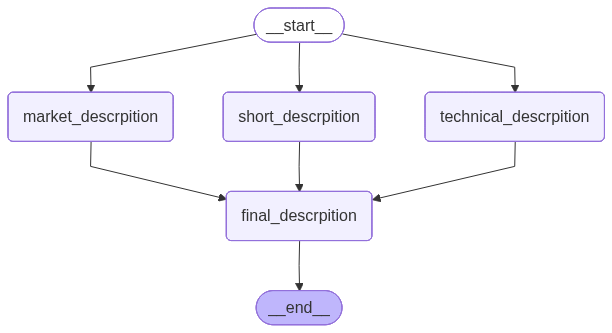

In [11]:
workflow

In [17]:
initial_state={
    "product_name": "Astro Khurshid AC DC fan."
}
final_state = workflow.invoke(initial_state)

In [18]:
print(final_state)

{'product_name': 'Astro Khurshid AC DC fan.', 'short_descrpition': [{'type': 'text', 'text': 'Here are a few options for a short description of the **Astro Khurshid AC/DC Fan**, depending on where you plan to use it:\n\n**Option 1: Concise & Feature-Focused (Best for e-commerce sites like Daraz or Amazon)**\n> "Experience uninterrupted cooling and maximum energy savings with the **Astro Khurshid AC/DC Fan**. Engineered to run seamlessly on both standard AC electricity and 12V DC battery/solar power, this high-performance fan features a whisper-quiet copper motor and modern design. It’s the perfect solution for reliable comfort during power outages and lower utility bills."\n\n**Option 2: Ultra-Short (Best for social media or quick product cards)**\n> "Stay cool and save energy with the **Astro Khurshid AC/DC Fan**. Offering dual-power convenience (AC grid & 12V solar/battery), this premium fan delivers powerful airflow and silent operation, ensuring uninterrupted comfort even during po

In [22]:
short_descrpition = final_state['short_descrpition']
print(short_descrpition[0]['text'])

Here are a few options for a short description of the **Astro Khurshid AC/DC Fan**, depending on where you plan to use it:

**Option 1: Concise & Feature-Focused (Best for e-commerce sites like Daraz or Amazon)**
> "Experience uninterrupted cooling and maximum energy savings with the **Astro Khurshid AC/DC Fan**. Engineered to run seamlessly on both standard AC electricity and 12V DC battery/solar power, this high-performance fan features a whisper-quiet copper motor and modern design. It’s the perfect solution for reliable comfort during power outages and lower utility bills."

**Option 2: Ultra-Short (Best for social media or quick product cards)**
> "Stay cool and save energy with the **Astro Khurshid AC/DC Fan**. Offering dual-power convenience (AC grid & 12V solar/battery), this premium fan delivers powerful airflow and silent operation, ensuring uninterrupted comfort even during power cuts."

**Option 3: Bulleted/Key Highlights**
> **Astro Khurshid AC/DC Fan** – The ultimate ener

In [24]:
market_descrpition = final_state['market_descrpition']
print(market_descrpition[0]['text'])

Here are a few options for the market description of the **Astro Khurshid AC DC Fan**, ranging from a comprehensive e-commerce description to a short, punchy social media ad copy.

### Option 1: Comprehensive E-Commerce Description (Best for websites like Daraz, Amazon, or Shopify)

**Product Title:** Astro Khurshid AC/DC Ceiling Fan – Ultimate Energy-Saving & Smart Cooling Solution

**Description:**
Beat the heat and slash your electricity bills with the **Astro Khurshid AC/DC Fan**. Engineered with cutting-edge technology and premium aesthetics, this fan is the perfect blend of style, durability, and energy efficiency. 

Designed to combat frequent power outages and high energy costs, the Astro Khurshid fan runs seamlessly on both **AC 220V (regular grid electricity)** and **DC 12V (batteries or solar power panels)**. Equipped with a high-efficiency Brushless DC (BLDC) motor, it consumes up to **60-70% less energy** compared to conventional ceiling fans, making it an eco-friendly and

In [25]:
technical_descrpition = final_state['technical_descrpition']
print(technical_descrpition[0]['text'])

Here is a comprehensive technical description for the **Astro Khurshid AC/DC Fan**. This is formatted as a professional technical datasheet, suitable for e-commerce, product manuals, or B2B presentations.

---

# Technical Datasheet: Astro Khurshid AC/DC Ceiling Fan

## 1. Product Overview
The **Astro Khurshid AC/DC Ceiling Fan** is a premium, high-efficiency hybrid ceiling fan designed for dual-power operation. Equipped with an advanced Brushless DC (BLDC) motor, it seamlessly runs on both standard alternating current (AC grid power) and direct current (DC battery or solar power). Engineered for tropical and high-temperature climates, this fan offers up to 60% energy savings compared to conventional induction motor fans, making it ideal for areas with frequent power outages (load shedding) or solar-powered installations.

---

## 2. Key Technical Features
*   **Dual-Input Smart Hybrid System:** Automatically switches between AC (220V) and DC (12V) power inputs without interruption.
* 